In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
df_raw = pd.read_csv('EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

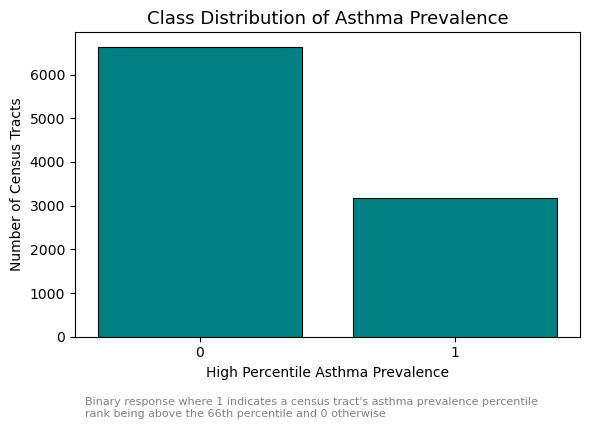

In [3]:

import matplotlib.pyplot as plt

# Count of each class
counts = df['F_ASTHMA'].value_counts()

# Define class labels
labels = ['0', '1']

# Create bar plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color='teal', edgecolor='black', linewidth=0.8)
ax.set_title("Class Distribution of Asthma Prevalence", fontsize=13)
fig.text(0.15, -0.055, "Binary response where 1 indicates a census tract's asthma prevalence percentile\nrank being above the 66th percentile and 0 otherwise", ha='left', fontsize=8, color='gray')
ax.set_xlabel("High Percentile Asthma Prevalence")
ax.set_ylabel("Number of Census Tracts")

plt.tight_layout()
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 

There is a class imbalance between the count of census tracts being designated as 0 or 1 based on their asthma prevalence percentile ranks, where the 0 class of census tracts not above the 66th percentile is much larger than that of the 1 class (~6500 compared to ~3200). This can affect our classification algorithm because we have to ensure that we have enough of each class in each fold when we conduct cross validation, which can be done using a stratified k-fold to preserve class proportions. When assessing the model accuracy, we need to take into account the uneven distribtuion of classes when analyzing the confusion matrix and interpreting the accuracy metrics, because the overall accuracy might be misleading and precision or recall might be more informative about how the class 1 census tracts are being classified. 

<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [4]:
# Create list variables to include
var_of_interest = ['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'F_ASTHMA']

# Create dataframe 
df_model = df[var_of_interest].dropna()

# Create variables for predictors and response
X = df_model[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']].values
y = df_model['F_ASTHMA']

# 70/30 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')

Training set : 6,813 tracts
Test set     : 2,920 tracts


In [5]:
grader.check("q3")

q3 results: All test cases passed!

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [6]:
# Initialize KNN
knn3 = KNeighborsClassifier(n_neighbors=3)

# Fit on training data
knn3.fit(X_train, y_train)

# Predict on test data
y_pred_knn3   = knn3.predict(X_test)

# Evaluate
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


In [7]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

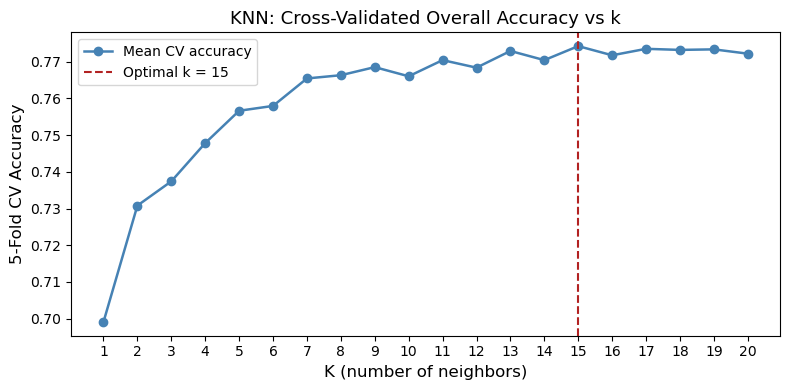

Optimal K = 15,  best mean CV accuracy = 0.7743


In [8]:
# Create list of K to test
k_values       = list(range(1,21))

# Create empty list to store mean CV scores
cv_mean_scores = [] 

# For loop to calculate mean CV score for each K
for k in k_values:
    # Initialize KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Compute mean and SD of overall accuracy on training set
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = "accuracy")

    cv_mean_scores.append(scores.mean())

# Convert to array to easily get min/max
cv_mean_scores = np.array(cv_mean_scores)

# Find optimal k- highest mean CV score
optimal_k     = k_values[np.argmax(cv_mean_scores)]

# Store best score
best_cv_score = cv_mean_scores.max()

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 4))  
ax.plot(k_values, cv_mean_scores, marker='o', color='steelblue', linewidth=1.8, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='firebrick', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=13) 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [9]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

Using cross-validation gives a better estimate of which K is optimal by rotating through multiple train/validation splits on the training data. This removes the high variance from any single split that comes from what observations landed where in that instance. It also removes the issue of training on fewer observations by ensuring that every observation in the training set is used for training and validation at some point across the fold rotations, giving a less biased estimate of the optimal K.

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [10]:
# Run KNN with the optimal k from CV
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)

# Fit on training data
knn_optimal.fit(X_train, y_train)

# Predict on test data
y_pred_knn_optimal   = knn_optimal.predict(X_test)

# Evaluate
knn_optimal_accuracy = accuracy_score(y_test, y_pred_knn_optimal)

print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')

KNN (K=15) test accuracy: 0.7760


In [11]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->


> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?

The test-set accuracy of the K=3 model was 0.7418, while the test-set accuracy of the model using the optimal K of 15 was slightly improved at 0.7760 (by about 0.03). The optimal K found by cross-validation likely outperformed the arbitrary choice of K=3 because the smaller K might learn the noise in the training data rather than the true underlying pattern, causing overfitting. A larger K (15) minimizes the error and is more generalizable, but is not too large to underfit the data.

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [12]:
# Create Logistic Regression CV
lr = LogisticRegressionCV(random_state=42, cv=5)

# Fit logistic model on full training set
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr   = lr.predict(X_test)

# Compute test-set accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.7753424657534247

In [13]:
# Extract coefficents from linear regression
lr_coef = lr.coef_[0]
lr_intercept = lr.intercept_[0]

# Create table
coef_table = pd.DataFrame({
    'Feature': ['Intercept', 'EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY'],
    'Coefficient': [lr_intercept] + list(lr_coef)
})
coef_table.style.hide(axis='index')

Feature,Coefficient
Intercept,-3.320082
EPL_POV200,5.008554
EPL_UNEMP,0.891915
EPL_MINRTY,-1.379598


In [14]:
grader.check("q9")

q9 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

The predictor `EPL_MINRTY` as well as the intercept have negative associations with a tract being flagged for high asthma prevalence. A negative coefficent means that as the percentile rank for the share of residents identifying as a racial or ethnic minority in a census tract increases, the log-odds of a census tract being flagged for high asthma prevalence decrease, and therefore the probability of high asthma prevalence decreases. Higher percentages of racial or ethnic minorities are associated with lower asthma prevalence in census tracts.

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

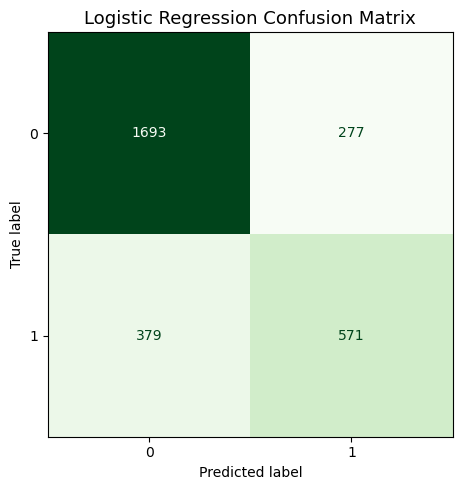

In [15]:
# Compute confusion matrix for logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                              display_labels=['0', '1'])

# Plot CM
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar = False, cmap = "Greens")
ax.set_ylim(len(['0', '1']) - 0.5, -0.5)
ax.set_title('Logistic Regression Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
grader.check("q11")

q11 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

False positives- 277 census tracts were misclassified as having a high percentile asthma prevalence.
True positives- 571 census tracts were correctly classified has having a high percentile asthma prevalence.
False negatives- 379 census tracts were misclassified as having a low percentile asthma prevalence.
True negatives- 1693 census tracts were correctly classified as having a low percentile asthma prevalence.

<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [17]:
# Compute accuracy metrics
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)

print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

Accuracy  = 0.7753
Precision = 0.6733
Recall    = 0.6011
F1 Score  = 0.6352


In [18]:
grader.check("q13")

q13 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

The results show that the logistic regression model has a high overall accuracy of 0.7753, but scored lower on the more specific summary metrics. Precision (0.6733) was higher than recall (0.6011), and the F1 score reflected the balance of these as 0.6352. In the context of predicting high asthma risk tracts, I think that recall would be the most important metric as we would want to identify the highest fraction of the truly high percentile asthma prevalence census tracts for intervention or informed decision-making. This is especially important as there are less tracts in the positive class, so the tradeoff is the model being less precise and predicting some low census tracts as high.

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

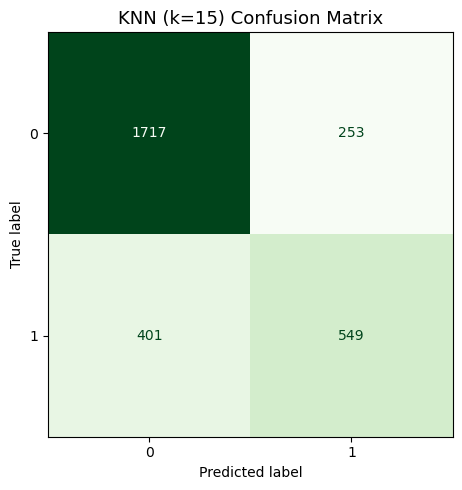

KNN (k=15) Confusion Matrix:
[[1717  253]
 [ 401  549]]

Precision (KNN): 0.6845
Recall    (KNN): 0.5779
F1 Score  (KNN): 0.6267

--- Model Comparison ---
              KNN (k=15)    Logistic Reg
Accuracy:     0.7760         0.7753
F1 Score:     0.6267         0.6352


In [19]:
# Compute confusion matrix for optimal K KNN
cm_knn = confusion_matrix(y_test, y_pred_knn_optimal)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=['0', '1'])

# Plot CM
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar = False, cmap = "Greens")
ax.set_ylim(len(['0', '1']) - 0.5, -0.5)
ax.set_title('KNN (k=15) Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Compute accuracy metrics
precision_knn = precision_score(y_test, y_pred_knn_optimal)
recall_knn    = recall_score(y_test, y_pred_knn_optimal)
f1_knn        = f1_score(y_test, y_pred_knn_optimal)

print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

In [20]:
grader.check("q15")

q15 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why? 

The logistic regression and KNN had a very similar overall accuracy with KNN slightly higher at 0.7760. The F1 score for logistic regression was also very similar but slightly higher at 0.6352. Because these metrics were very similar and recall is important in the context of asthma identification, I would select logistic regression as it had the highest recall value. This would also benefit the analysis beyond just classification of census tracts as we would have more information about the effect of the individual predictors (poverty, unemployment, race and ethnicity) on asthma prevalence. 

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

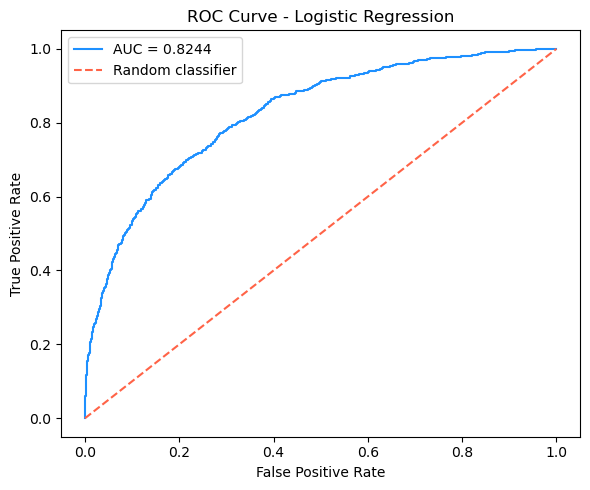

Logistic Regression AUC: 0.8244


In [21]:
# Get predicted probabilities
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='Dodgerblue', label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='tomato', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Logistic Regression AUC: {roc_auc:.4f}')

In [22]:
grader.check("q17")

q17 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q7:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

The AUC score of 0.8244 tells us that the logistic regression model has good discriminating ability between high and low asthma risk tracts. This model is better than random guessing, which is shown in the plot as the random classfier line at an AUC score of 0.5. The shape of the ROC curve reflects the precision-recall tradeoff because to achieve high recall and catch most high-risk tracts, the model will have more false positives. We want the highest true positive rate for identifying at-risk census tracts.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [23]:
grader.check_all()

q11 results: All test cases passed!

q13 results: All test cases passed!

q15 results: All test cases passed!

q17 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!